## 1. Import & Cấu hình

In [5]:
import json
import zipfile
from pathlib import Path

import cv2
import gdown
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm

FILE_ID = "19bbKA0vrk2_-ZY2JAbNLT9WZL8BqZE5g"

BASE_DIR      = Path("/content")
CROPS_DIR     = BASE_DIR / "cropped_fields"
MANIFEST_PATH = CROPS_DIR / "manifest.jsonl"
OUT_DIR       = BASE_DIR / "ocr_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH      = OUT_DIR / "pseudo_labels.jsonl"

PADDLE_FIELDS  = ["id", "birth"]
VIETOCR_FIELDS = ["name", "origin", "address", "title"]

print(f"Crops dir: {CROPS_DIR}")
print(f"Output:    {OUT_PATH}")

Crops dir: /content/cropped_fields
Output:    /content/ocr_output/pseudo_labels.jsonl


## 1b. Download & giải nén data

In [6]:
zip_path = BASE_DIR / "cropped_fields.zip"
gdown.download(id=FILE_ID, output=str(zip_path), quiet=False)
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(str(BASE_DIR))

# Dem so crop
with open(MANIFEST_PATH, encoding="utf-8") as f:
    total = sum(1 for _ in f)
print(f" {total} crops")

Downloading...
From (original): https://drive.google.com/uc?id=19bbKA0vrk2_-ZY2JAbNLT9WZL8BqZE5g
From (redirected): https://drive.google.com/uc?id=19bbKA0vrk2_-ZY2JAbNLT9WZL8BqZE5g&confirm=t&uuid=8cc678f1-8e85-48a2-bf63-bc5f203a941f
To: /content/cropped_fields.zip
100%|██████████| 218M/218M [00:02<00:00, 98.0MB/s]


 22682 crops


## 2. Load models

In [7]:
!pip install paddlepaddle paddleocr vietocr pillow -q
!pip install gdown==4.4.0 -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 28.9 MB/s eta 0:00:00
   ━

In [18]:
# --- PaddleOCR ---
import os
import PIL._util

if not hasattr(PIL._util, "is_directory"):
    PIL._util.is_directory = os.path.isdir
if not hasattr(PIL._util, "is_path"):
    PIL._util.is_path = lambda f: isinstance(f, (str, bytes, os.PathLike))

from paddleocr import PaddleOCR

paddle_ocr = PaddleOCR(lang="en", device="gpu")


Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det

In [11]:
# --- VietOCR ---

from PIL import Image
if not hasattr(Image, "ANTIALIAS"):
    Image.ANTIALIAS = Image.LANCZOS

import torch
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

vietocr_cfg = Cfg.load_config_from_name("vgg_transformer")
vietocr_cfg["cnn"]["pretrained"] = True
vietocr_cfg["device"] = "cuda:0" if torch.cuda.is_available() else "cpu"

vietocr_model = Predictor(vietocr_cfg)
print(f"VietOCR loaded on {vietocr_cfg['device']}.")

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 203MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:18, 1010.98it/s]


VietOCR loaded on cuda:0.


## 3. Hàm OCR

In [20]:
def run_paddleocr(img_path: str) -> tuple:
    # PaddleOCR không tương thích với môi trường này
    # fallback về VietOCR
    return run_vietocr(img_path)




def run_vietocr(img_path: str) -> tuple:
    img = Image.open(img_path).convert("RGB")
    text, conf = vietocr_model.predict(img, return_prob=True)
    return text, float(conf)



## 4. Chạy pseudo-label

In [22]:
with open(MANIFEST_PATH, encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

print(f"Tong: {len(records)} crops")

results = []
errors  = 0


#for rec in tqdm(records[:100], desc="OCR"):
for rec in tqdm(records, desc="OCR"):
    rel = rec["path"].replace("\\", "/").replace("data/interim/cropped_fields/", "")
    img_path = str(CROPS_DIR / rel)
    cls = rec["class"]

    try:
        text_paddle, conf_paddle = run_paddleocr(img_path)
        text_vietocr, conf_vietocr = run_vietocr(img_path)
    except Exception:
        errors += 1
        continue

    if cls in PADDLE_FIELDS:
        best_text = text_paddle if conf_paddle >= conf_vietocr else text_vietocr
    else:
        best_text = text_vietocr if conf_vietocr >= conf_paddle else text_paddle
    best_conf = max(conf_paddle, conf_vietocr)

    results.append({
        "crop_path":      rec["path"],
        "class":          cls,
        "split":          rec["split"],
        "text_paddleocr": text_paddle,
        "conf_paddleocr": round(conf_paddle, 4),
        "text_vietocr":   text_vietocr,
        "conf_vietocr":   round(conf_vietocr, 4),
        "best_text":      best_text,
        "best_conf":      round(best_conf, 4),
    })

print(f"\nXong: {len(results)} results, {errors} errors")


Tong: 22682 crops


OCR:   0%|          | 0/22682 [00:00<?, ?it/s]


Xong: 22682 results, 0 errors


## 5. Lưu pseudo_labels.jsonl

In [23]:
with open(OUT_PATH, "w", encoding="utf-8") as f:
    for rec in results:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print(f"Saved: {OUT_PATH}")
print(f"Total records: {len(results)}")

Saved: /content/ocr_output/pseudo_labels.jsonl
Total records: 22682


## 6. Thống kê confidence

Phan loai theo confidence
  High   (>= 0.9):  9387 (41.4%) — accept
  Medium (0.5-0.9):  9967 (43.9%) — can review
  Low    (< 0.5):  3328 (14.7%) — can gan thu cong

Confidence trung binh theo class
  id        : 0.8968
  name      : 0.8957
  birth     : 0.8745
  origin    : 0.5545
  address   : 0.5194
  title     : 0.8669


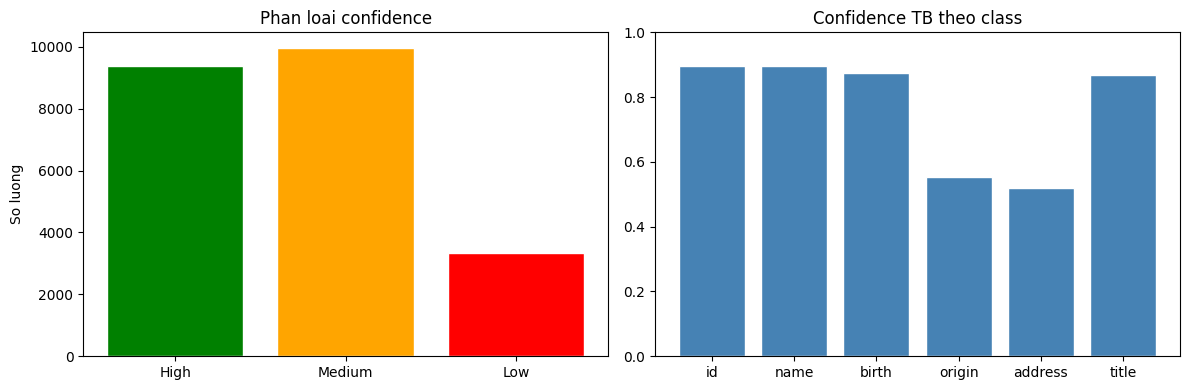

In [24]:
import matplotlib.pyplot as plt

high   = [r for r in results if r["best_conf"] >= 0.9]
medium = [r for r in results if 0.5 <= r["best_conf"] < 0.9]
low    = [r for r in results if r["best_conf"] < 0.5]

print("Phan loai theo confidence")
print(f"  High   (>= 0.9): {len(high):5d} ({len(high)/len(results)*100:.1f}%) — accept")
print(f"  Medium (0.5-0.9): {len(medium):5d} ({len(medium)/len(results)*100:.1f}%) — can review")
print(f"  Low    (< 0.5): {len(low):5d} ({len(low)/len(results)*100:.1f}%) — can gan thu cong")

print("\nConfidence trung binh theo class")
classes = ["id", "name", "birth", "origin", "address", "title"]
class_confs = {}
for cls in classes:
    confs = [r["best_conf"] for r in results if r["class"] == cls]
    avg = np.mean(confs) if confs else 0
    class_confs[cls] = avg
    print(f"  {cls:10s}: {avg:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(["High", "Medium", "Low"], [len(high), len(medium), len(low)],
        color=["green", "orange", "red"], edgecolor="white")
ax1.set_title("Phan loai confidence")
ax1.set_ylabel("So luong")
ax2.bar(classes, [class_confs[c] for c in classes], color="steelblue", edgecolor="white")
ax2.set_title("Confidence TB theo class")
ax2.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Xem thử một số kết quả

In [25]:
for cls in classes:
    samples = [r for r in results if r["class"] == cls][:3]
    print(f"\n--- {cls} ---")
    for s in samples:
        print(f"  PaddleOCR: {s['text_paddleocr']!r:30s} (conf={s['conf_paddleocr']})")
        print(f"  VietOCR:   {s['text_vietocr']!r:30s} (conf={s['conf_vietocr']})")
        print(f"  Best:      {s['best_text']!r:30s} (conf={s['best_conf']})")
        print()


--- id ---
  PaddleOCR: '001188033489'                 (conf=0.926)
  VietOCR:   '001188033489'                 (conf=0.926)
  Best:      '001188033489'                 (conf=0.926)

  PaddleOCR: '026002036'                    (conf=0.868)
  VietOCR:   '026002036'                    (conf=0.868)
  Best:      '026002036'                    (conf=0.868)

  PaddleOCR: '079304016111'                 (conf=0.9286)
  VietOCR:   '079304016111'                 (conf=0.9286)
  Best:      '079304016111'                 (conf=0.9286)


--- name ---
  PaddleOCR: 'NGÔ THỊ HUYỀN TRANG'          (conf=0.9266)
  VietOCR:   'NGÔ THỊ HUYỀN TRANG'          (conf=0.9266)
  Best:      'NGÔ THỊ HUYỀN TRANG'          (conf=0.9266)

  PaddleOCR: 'TRẦN THỊ HĨ TRANG'            (conf=0.7394)
  VietOCR:   'TRẦN THỊ HĨ TRANG'            (conf=0.7394)
  Best:      'TRẦN THỊ HĨ TRANG'            (conf=0.7394)

  PaddleOCR: 'ĐỐI HUYỆN PHÓNG TUYẾT'        (conf=0.7492)
  VietOCR:   'ĐỐI HUYỆN PHÓNG TUYẾT'        (co

## 8. Tải kết quả về máy

In [26]:
from google.colab import files

files.download(str(OUT_PATH))   # pseudo_labels.jsonl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>